* https://developer.apple.com/metal/tensorflow-plugin/
* https://www.youtube.com/watch?v=w2qlou7n7MA
* https://github.com/conda-forge/miniforge
* https://github.com/jeffheaton/t81_558_deep_learning/blob/master/install/tensorflow-install-mac-metal-jul-2021.ipynb
* https://github.com/jeffheaton/t81_558_deep_learning/blob/master/tensorflow-apple-metal.yml
* https://github.com/GPflow/GPflow
* `jupytext --to notebook regression.pct.py`

In [1]:
#pip install covasim gpflow

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_probability as tfp
import gpflow as gpf
from gpflow.utilities import print_summary

# The lines below are specific to the notebook format
%matplotlib inline
plt.rcParams["figure.figsize"] = (12, 6)

dtyp = np.float64
gpf.config.set_default_float(dtyp)

print("Tensorflow version " + tf.__version__)
print(f"Tensorflow Probability: {tfp.__version__}")
print(f"GPFlow {gpf.__version__}")
gpu = len(tf.config.list_physical_devices('GPU'))>0
print("GPU is", "available" if gpu else "NOT AVAILABLE")

try:
  tpu = tf.distribute.cluster_resolver.TPUClusterResolver()  # TPU detection
  print('Running on TPU ', tpu.cluster_spec().as_dict()['worker'])

  tf.config.experimental_connect_to_cluster(tpu)
  tf.tpu.experimental.initialize_tpu_system(tpu)
  tpu_strategy = tf.distribute.experimental.TPUStrategy(tpu)
except ValueError:
  msg = 'WARNING: Not connected to a TPU runtime; please see the previous cell in this notebook for instructions!'
  print(msg)

tf.config.experimental.set_visible_devices([], 'GPU') # Turn off GPU (for M1 Mac, hopefully temporary!)
#tf.config.set_soft_device_placement(True)
tf.debugging.set_log_device_placement(False)

print('Physical: ', tf.config.list_physical_devices())
print('Logical: ', tf.config.list_logical_devices())

Tensorflow version 2.8.0
Tensorflow Probability: 0.16.0
GPFlow 2.4.0
GPU is available
Physical:  [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Logical:  [LogicalDevice(name='/device:CPU:0', device_type='CPU')]


## Load training data

In [3]:
df = pd.read_csv('beta_sweep.csv')
X = df['log_beta'].values.reshape(-1, 1).astype(dtyp)
Y = df['cum_inf'].values.reshape(-1, 1).astype(dtyp)

# Normalize
Y = Y-Y.mean()
Y = 2 * Y / (Y.max() - Y.min())

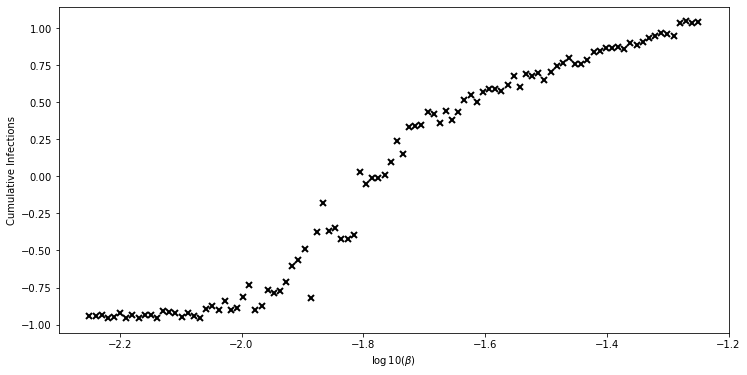

In [4]:
f, ax = plt.subplots();
ax.plot(X, Y, 'kx', mew=2);
ax.set_xlabel(r'$\log10(\beta$)');
ax.set_ylabel('Cumulative Infections');

In [5]:
k = gpf.kernels.Matern52()
print_summary(k)

╒═══════════════════════╤═══════════╤═════════════╤═════════╤═════════════╤═════════╤═════════╤═════════╕
│ name                  │ class     │ transform   │ prior   │ trainable   │ shape   │ dtype   │   value │
╞═══════════════════════╪═══════════╪═════════════╪═════════╪═════════════╪═════════╪═════════╪═════════╡
│ Matern52.variance     │ Parameter │ Softplus    │         │ True        │ ()      │ float64 │       1 │
├───────────────────────┼───────────┼─────────────┼─────────┼─────────────┼─────────┼─────────┼─────────┤
│ Matern52.lengthscales │ Parameter │ Softplus    │         │ True        │ ()      │ float64 │       1 │
╘═══════════════════════╧═══════════╧═════════════╧═════════╧═════════════╧═════════╧═════════╧═════════╛


In [6]:
m = gpf.models.GPR(data=(X, Y), kernel=k, mean_function=None)
m.likelihood.variance.assign(1)
m.kernel.lengthscales.assign(0.3)
m.kernel.variance.assign(1)
print_summary(m)

╒═════════════════════════╤═══════════╤══════════════════╤═════════╤═════════════╤═════════╤═════════╤═════════╕
│ name                    │ class     │ transform        │ prior   │ trainable   │ shape   │ dtype   │   value │
╞═════════════════════════╪═══════════╪══════════════════╪═════════╪═════════════╪═════════╪═════════╪═════════╡
│ GPR.kernel.variance     │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │     1   │
├─────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼─────────┤
│ GPR.kernel.lengthscales │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │     0.3 │
├─────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼─────────┤
│ GPR.likelihood.variance │ Parameter │ Softplus + Shift │         │ True        │ ()      │ float64 │     1   │
╘═════════════════════════╧═══════════╧══════════════════╧═════════╧═════════════╧═════════╧════

In [7]:
opt = gpf.optimizers.Scipy()

opt_logs = opt.minimize(m.training_loss, m.trainable_variables, options=dict(maxiter=10000))
print_summary(m)

2022-04-01 15:08:27.907449: W tensorflow/python/util/util.cc:368] Sets are not currently considered sequences, but this may change in the future, so consider avoiding using them.


╒═════════════════════════╤═══════════╤══════════════════╤═════════╤═════════════╤═════════╤═════════╤════════════╕
│ name                    │ class     │ transform        │ prior   │ trainable   │ shape   │ dtype   │      value │
╞═════════════════════════╪═══════════╪══════════════════╪═════════╪═════════════╪═════════╪═════════╪════════════╡
│ GPR.kernel.variance     │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 0.801043   │
├─────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼────────────┤
│ GPR.kernel.lengthscales │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 0.523163   │
├─────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼────────────┤
│ GPR.likelihood.variance │ Parameter │ Softplus + Shift │         │ True        │ ()      │ float64 │ 0.00441548 │
╘═════════════════════════╧═══════════╧══════════════════╧═════════╧════

2022-04-01 15:08:28.564939: W tensorflow/core/platform/profile_utils/cpu_utils.cc:128] Failed to get CPU frequency: 0 Hz


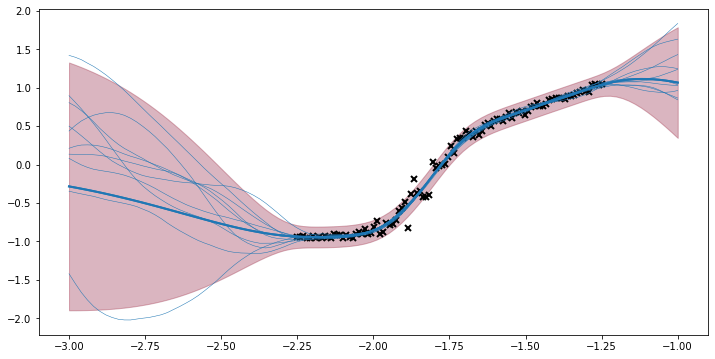

In [8]:
## generate test points for prediction
#xx = np.linspace(-0.1, 1.1, 100).reshape(100, 1)  # test points must be of shape (N, D)
xx = np.log10(np.logspace(-3, -1, 100)).reshape(100, 1).astype(dtyp)  # test points must be of shape (N, D)

## predict mean and variance of latent GP at test points
mean_f, var_f = m.predict_y(xx)
mean_y, var_y = m.predict_y(xx)

## generate 10 samples from posterior
tf.random.set_seed(1)  # for reproducibility
samples = m.predict_f_samples(xx, 10)  # shape (10, 100, 1)

## plot
plt.figure(figsize=(12, 6))
plt.plot(X, Y, "kx", mew=2)
def plot(mu, sig, col):
    plt.plot(xx, mu, "C0", lw=2)
    plt.fill_between(
        xx[:, 0],
        mu[:, 0] - 1.96 * np.sqrt(sig[:, 0]),
        mu[:, 0] + 1.96 * np.sqrt(sig[:, 0]),
        color=col,
        alpha=0.2,
    )
plot(mean_f, var_f, 'C0')
plot(mean_y, var_y, 'r')

plt.plot(xx, samples[:, :, 0].numpy().T, "C0", linewidth=0.5);